# Image Processing SoSe 2026 - Assignment - 04

### Deadline is 21.05.2026 at 11:55 a.m.

#### Students: Fabio Herrmann & Julius Böhm

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

In [1]:
from numpy.ma.core import arctan
# display the plots inside the notebook
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
from skimage.data import cat, coins
from skimage.color import rgb2gray, rgb2hsv, hsv2rgb

pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

# Part I: Exercise 1 - Implement a Histogram Mapping - 3 Points

In [3]:
def norm_cdf(arr):
    return arr / arr[-1]

In [4]:
def gamma_mapping(gamma):
    """
    Returns a 1-dimensional numpy array. The value of the array at the n-position 
    is `(n/len(array))**gamma`.
    """
    return norm_cdf(np.linspace(0, 1, 256)**gamma)


def sigmoid_mapping(gain = 10, cutoff = 0.5):
    """
    Returns a 1-dimensional numpy array. The value of the array at the n-position 
    is  `1/(1 + exp*(gain*(cutoff - (n/len(array)))))`.
    """
    return 1 / (1 + np.exp(gain * (cutoff - np.linspace(0,1,256))))

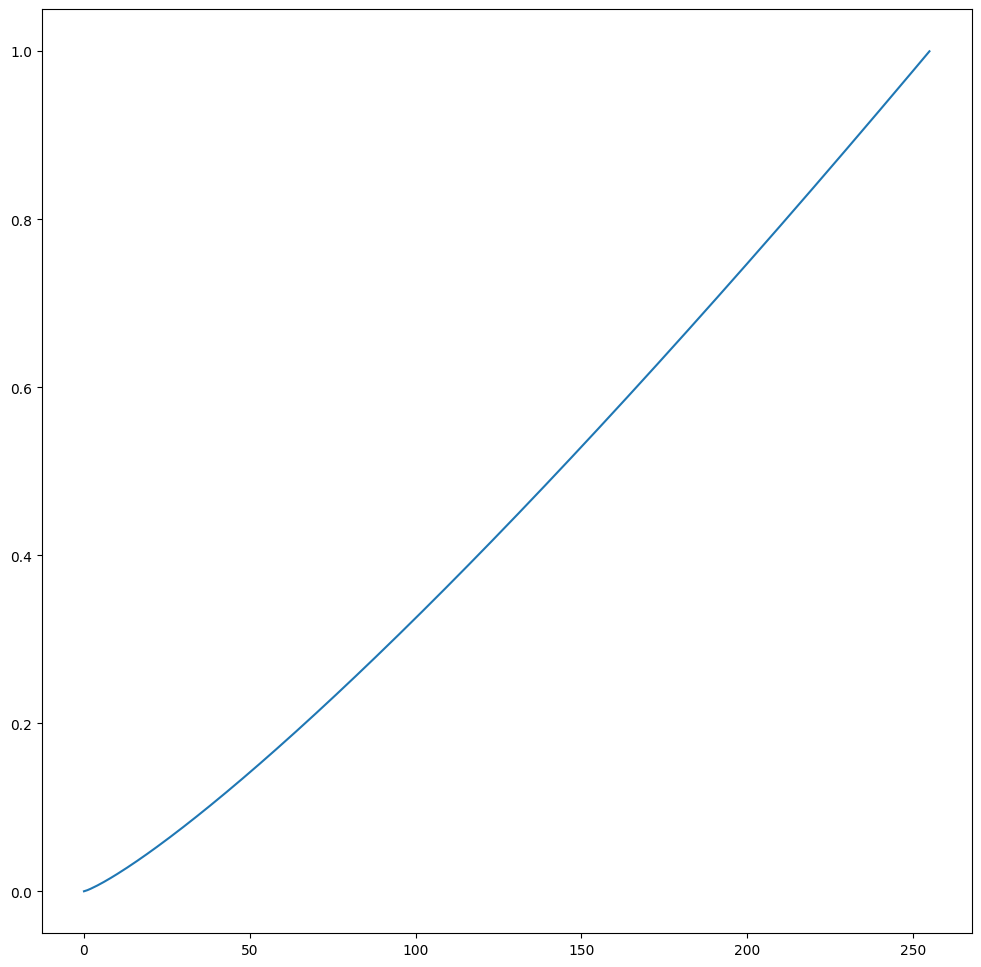

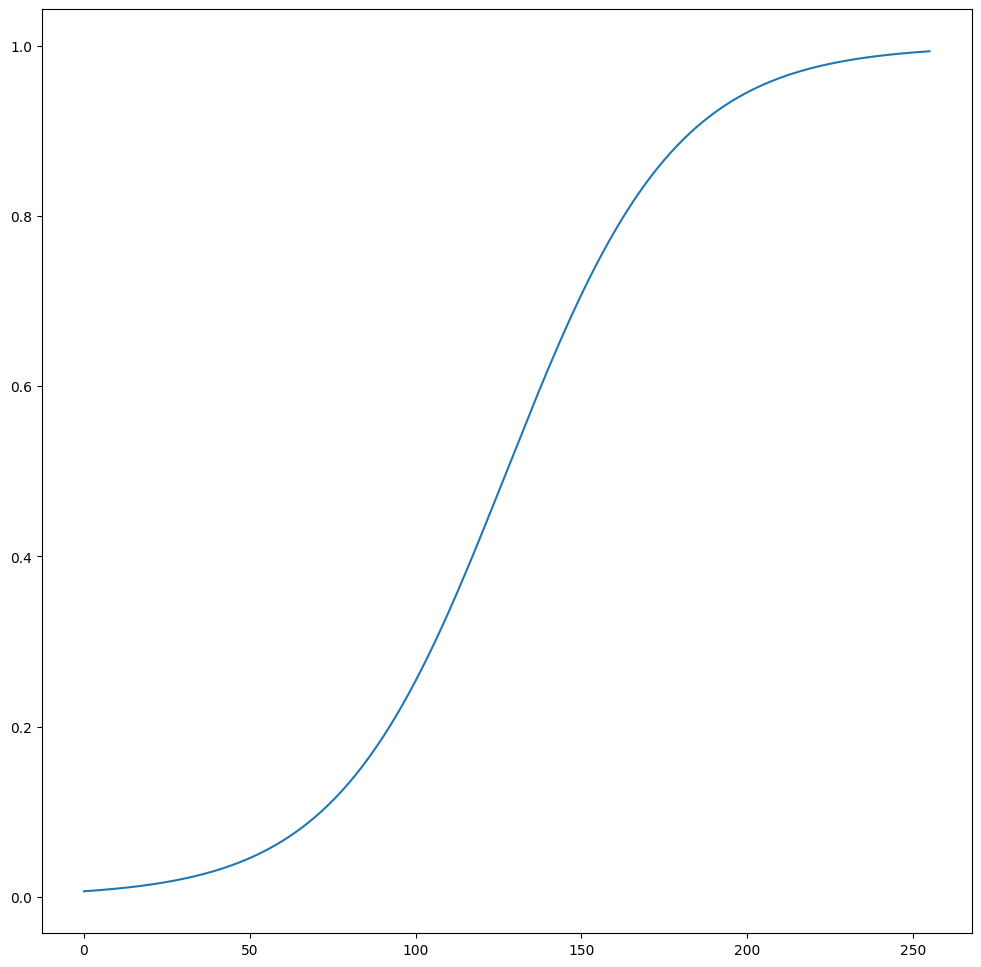

In [5]:
plt.plot(gamma_mapping(1.2))
plt.show()

plt.plot(sigmoid_mapping())
plt.show()

# Exercise 2 - Histogram Transformation - 4 Points

In [6]:
img = cat() / 255.
img_hsv = rgb2hsv(img)
img_gray = rgb2gray(img)

In [7]:
def apply_pixel_mapping(image, mapping):
    """Returns the image transformed according to the mapping array. 
       `mapping` is a one dimensional numpy array. `image` can be 2 or 3-dimensional.
       The values of the image are in range 0 to 1.
       If the mapping has for example 255 items, then all pixel with a value from 0 to 1/255 are assigned to 
       the value mapping[0]. If the pixel is between n / 255 and (n+1) / 255 then the value in the output image should 
       be mapping[n]
    """
    img = np.copy(image)

    indices = np.clip((img * 255).astype(int), 0, 255)

    img = mapping[indices]

    return img

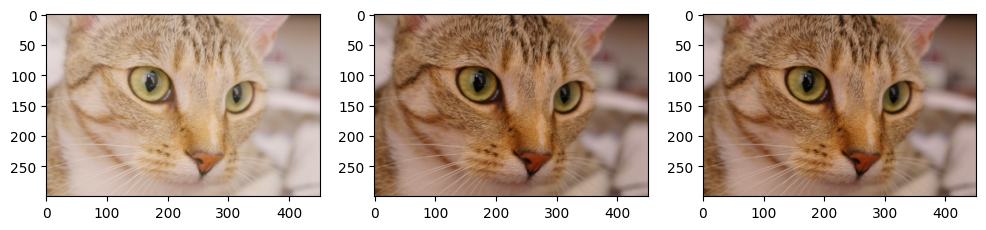

In [8]:
# you can test your `apply_pixel_mapping` function
# The first image should look lighter. The second and third should be the same image.
img_gamma05 = apply_pixel_mapping(img, gamma_mapping(0.5))
plt.subplot(131)
plt.imshow(img_gamma05)
plt.subplot(132)
plt.imshow(apply_pixel_mapping(img_gamma05, gamma_mapping(2)))
plt.subplot(133)
plt.imshow(img)
plt.show()

# Exercise 3 - Implement Histogram Equalization - 3 Points

Equalize the image given image so that the histogram is mostly uniform distributed.
You can use `np.histogram` and `np.cumsum`. Checkout the documentation of `np.histogram`, it might have useful optional arguments.

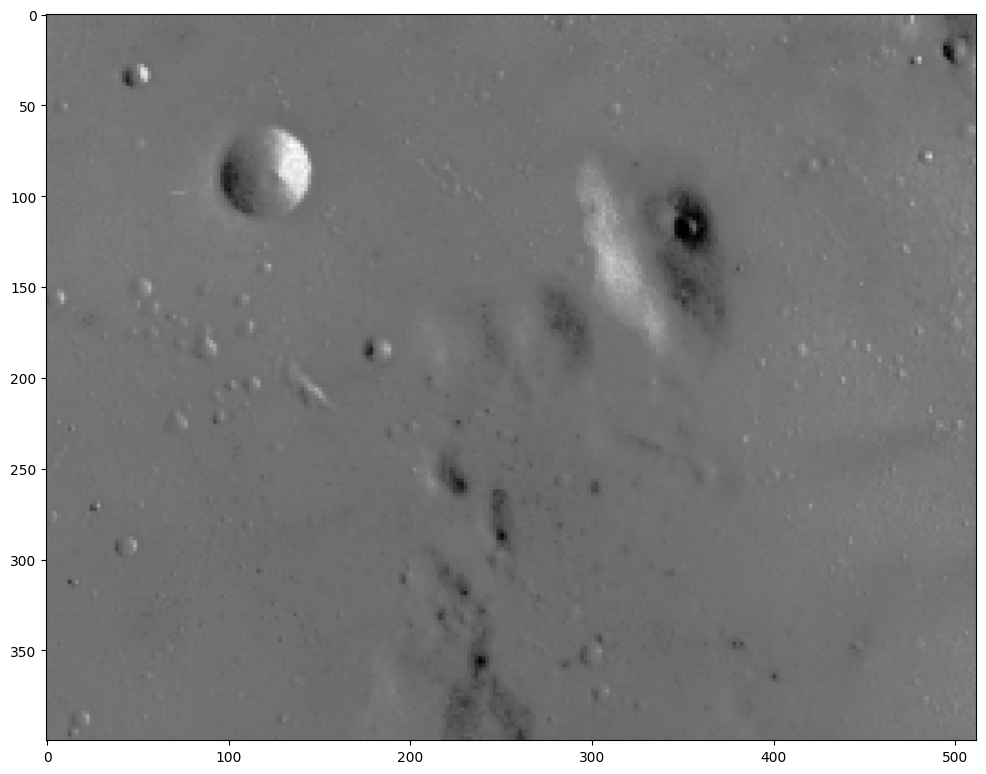

In [9]:
from skimage import data
moon = data.moon()[:400,:] / 255.
plt.imshow(moon, cmap='gray', vmin=0, vmax=1)
plt.show()

In [10]:
hist = np.histogram(moon, bins=256, range=(0,1))[0] # get the histogram of the image

cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

equalisation_mapping = cdf

In [11]:
img_equalised = apply_pixel_mapping(moon, equalisation_mapping)

In [12]:
hist_of_equalised = np.histogram(img_equalised, bins=256, range=(0,1))[0] # get the histogram of the equalised image

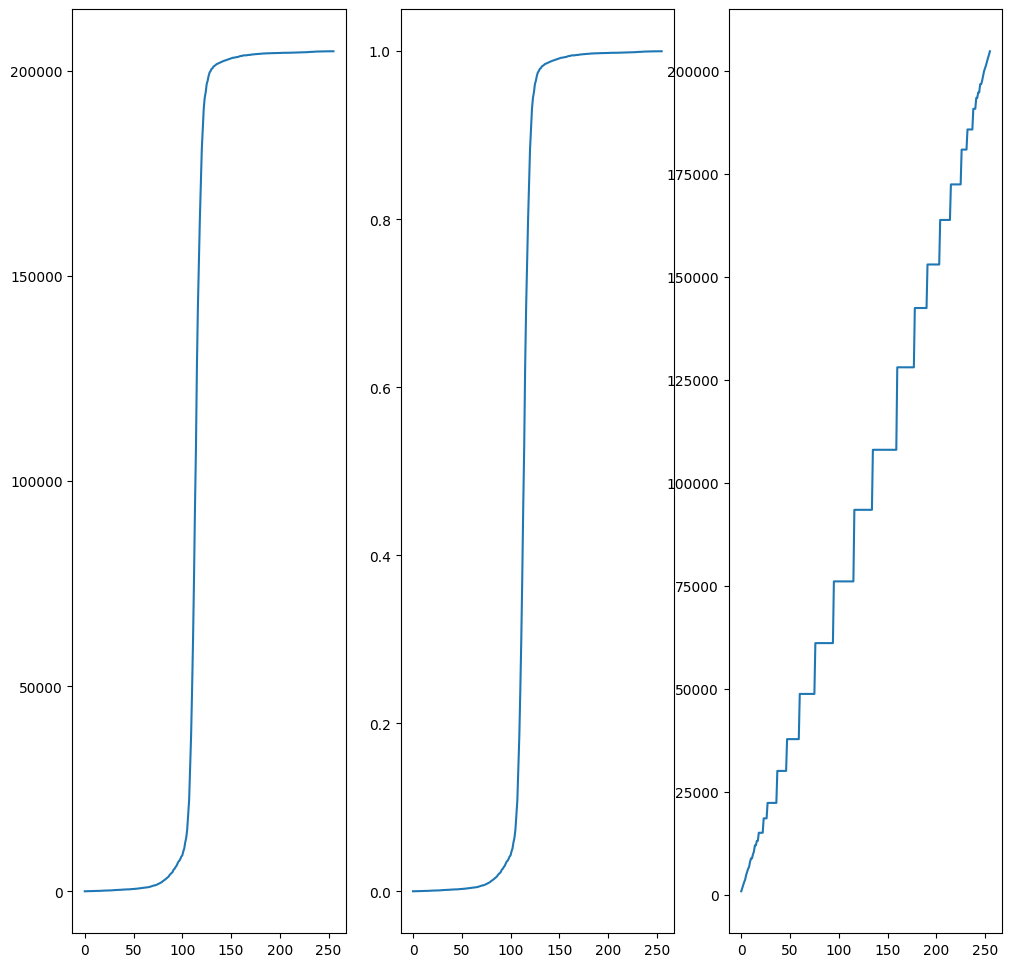

In [13]:
plt.subplot(131)
plt.plot(hist.cumsum())
plt.subplot(132)
plt.plot(equalisation_mapping)
plt.subplot(133)
plt.plot(hist_of_equalised.cumsum())
plt.show()

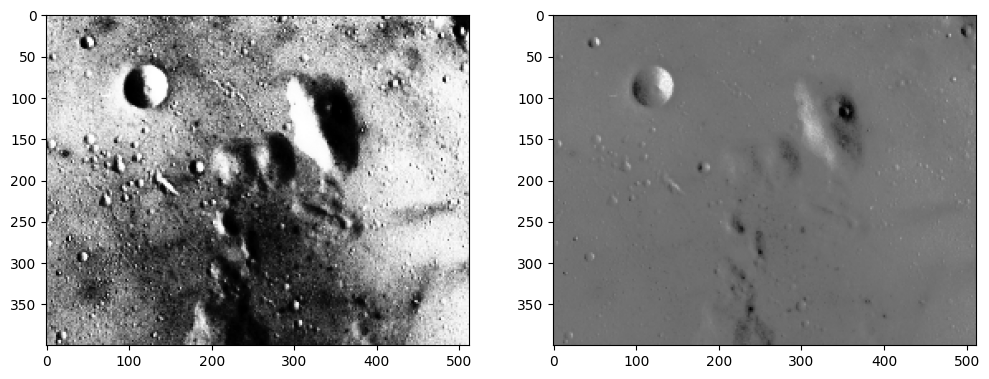

In [14]:
plt.subplot(121)
plt.imshow(img_equalised, cmap='gray', vmin=0, vmax=1)
plt.subplot(122)
plt.imshow(moon, cmap='gray', vmin=0, vmax=1)
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
import random
from io import BytesIO
from PIL import Image

pylab.rcParams['figure.figsize'] = (12, 12)  # This makes the plot bigger

# Part II: Exercise 4 - Qualify sharpness and noise - 5 Points

Determine the noise and sharpness in the images. Plot image number vs noise

Please download sample picture from [here](http://sipi.usc.edu/database/misc.zip) and place them next to your assignment (inside the misc folder).

In [16]:
# Load the pictures here
sample_images = []
direc = 'misc/' # directory of the sample pictures relative to your notebook
for number in [1,3,5,6]:
    sample_images.append(np.array(Image.open(direc+'4.2.0'+str(number)+'.tiff')))
for name in ['house']:
    sample_images.append(np.array(Image.open(direc+name+'.tiff')))

<BarContainer object of 5 artists>

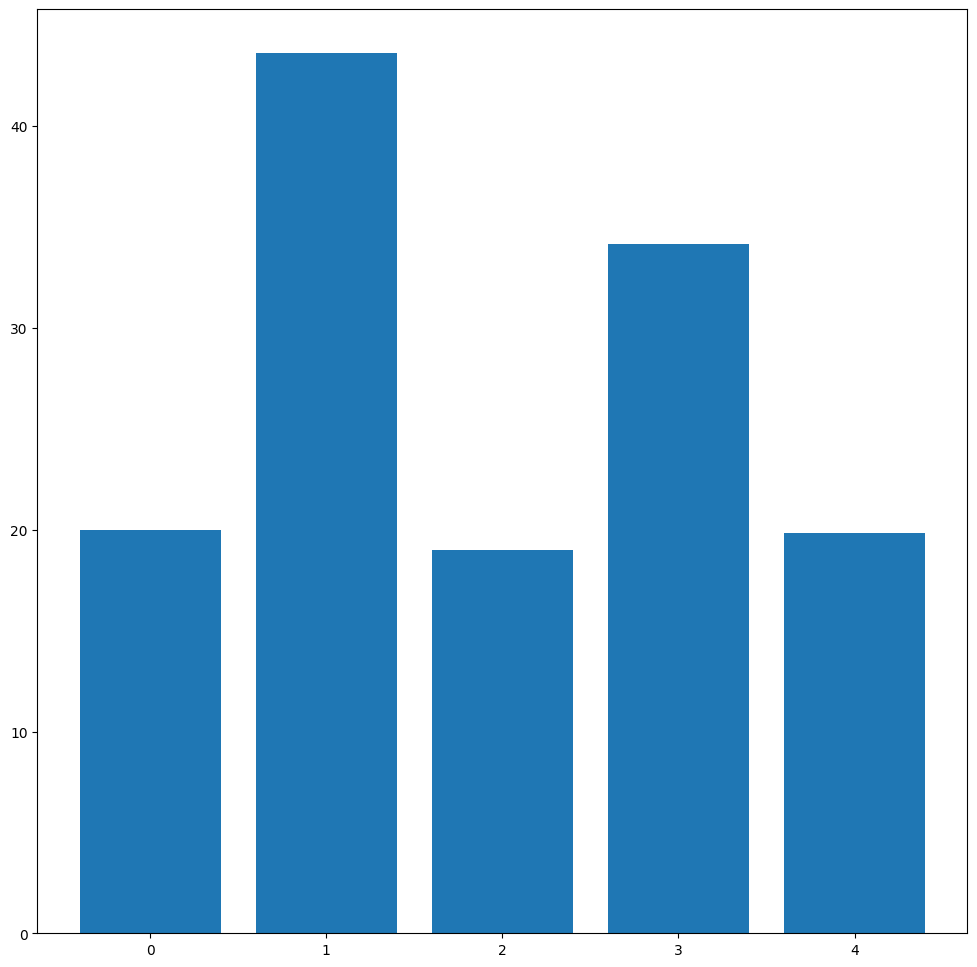

In [17]:
def qualify_noise(img):
    """Qualify the noise based on the std of a gaussian model.
       You may find a window that is constant in the images.
    """

    #We define a window in the top-middle since its pretty similar in all the pictures

    h, w = img.shape[:2]
    center_x = w // 2

    patch = img[0:30, center_x-15:center_x+15]

    return np.std(patch)

plt.bar(range(len(sample_images)), [qualify_noise(i) for i in sample_images])


<BarContainer object of 5 artists>

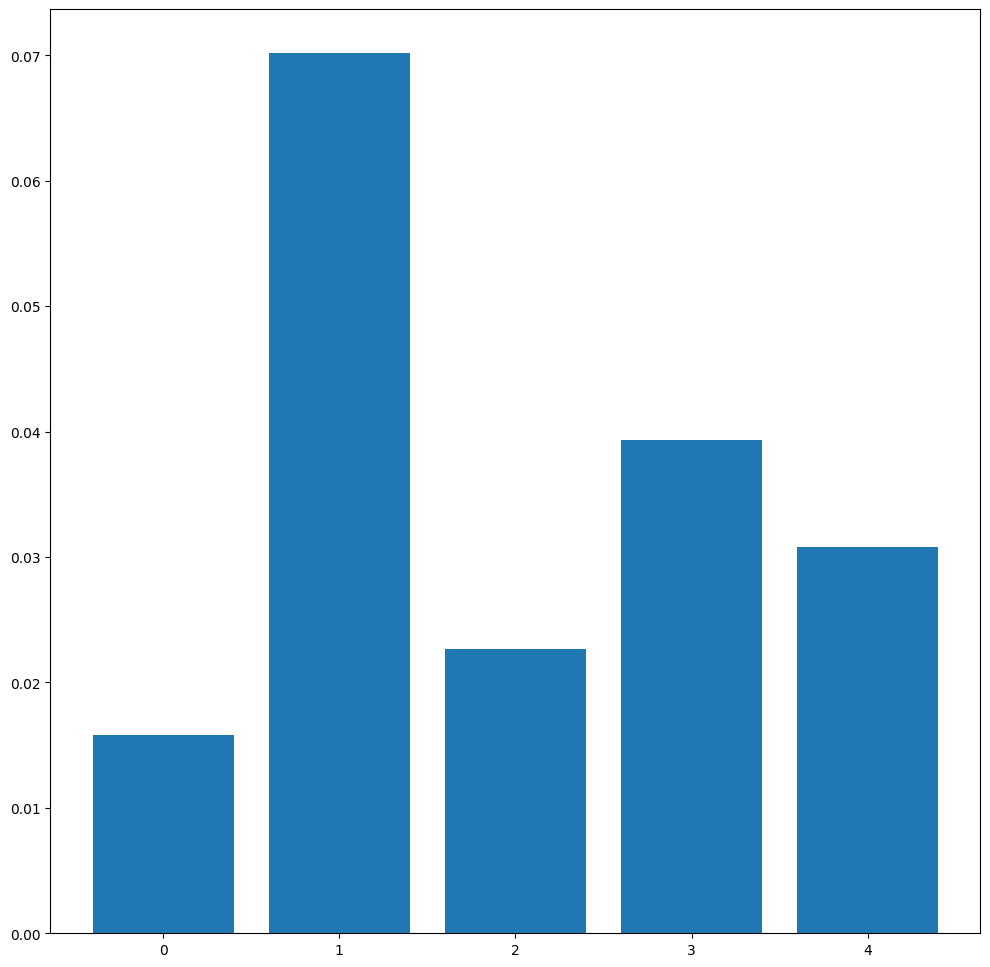

In [18]:
def qualify_sharpness(img):
    """Qualify the sharpness based on the average pixel differences."""

    #measuring the sharpness in a black and white image 
    if img.ndim == 3:
        img = rgb2gray(img)

    diff_h = img[:, :-1] - img[:, 1:]
    diff_v = img[:-1, :] - img[1:, :]

    diff_h = np.abs(diff_h)
    diff_v = np.abs(diff_v)

    return (np.mean(diff_h) + np.mean(diff_v)) / 2

plt.bar(range(len(sample_images)), [qualify_sharpness(i) for i in sample_images])

Does the result match your expectations? If not what processing step can be done?

It does mostly but:

defining sharpness as the mean difference in lighting of pixels lets pictures with more even lighting or color be counted as less sharp (if we understood the lecture correctly ;)). Taking the color differences in account might help. (can we take the color spectrum as a 1 dimensional array to therefore find again differences in color to take in account with the lighting?)

Or use a method like SSIM

# Exercise 5 - SSIM JPEG Compression - 5 Points
Implement the SSIM metric and apply it on the given compressed images

In [19]:
def jpeg_encode(img, quality):
    pil_img = Image.fromarray(img)
    buffer = BytesIO()
    pil_img.save(buffer, "JPEG", quality=quality)
    return buffer

def jpeg_decode(buffer):
    img = Image.open(buffer)
    return np.array(img)

def jpeg_quality_filter(img, quality):
    as_jpeg = jpeg_encode(img, quality)
    return jpeg_decode(as_jpeg)

In [20]:
images_for_jpeg = sample_images[2::]
len(images_for_jpeg)

3

In [21]:
images10 = [jpeg_quality_filter(img, 10) for img in images_for_jpeg]
images50 = [jpeg_quality_filter(img, 50) for img in images_for_jpeg]
images80 = [jpeg_quality_filter(img, 80) for img in images_for_jpeg]

0


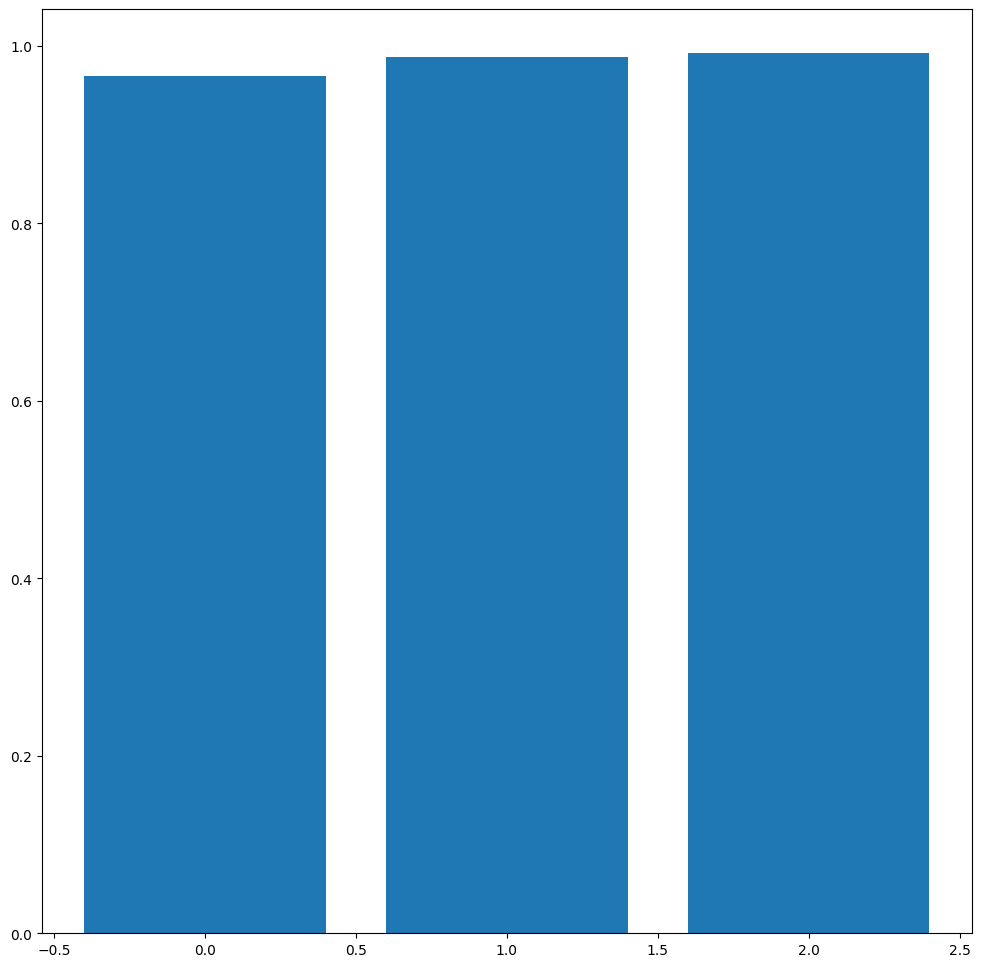

1


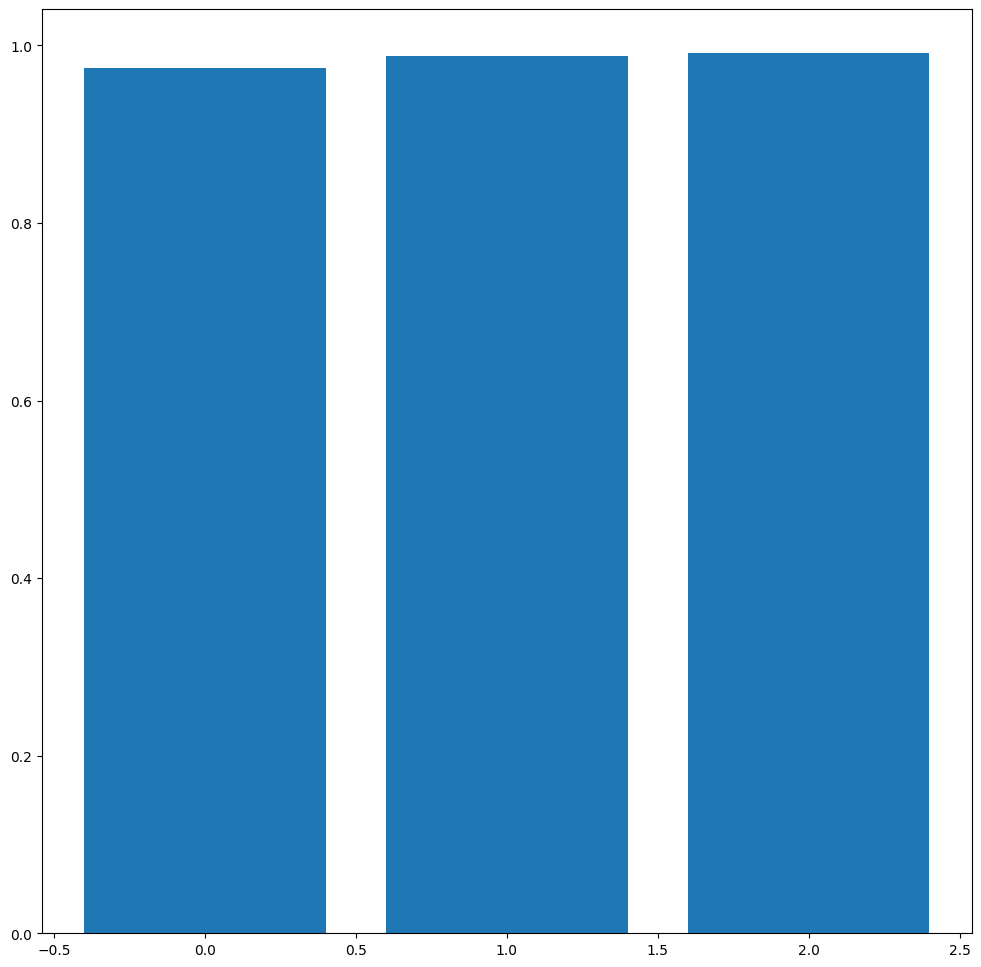

2


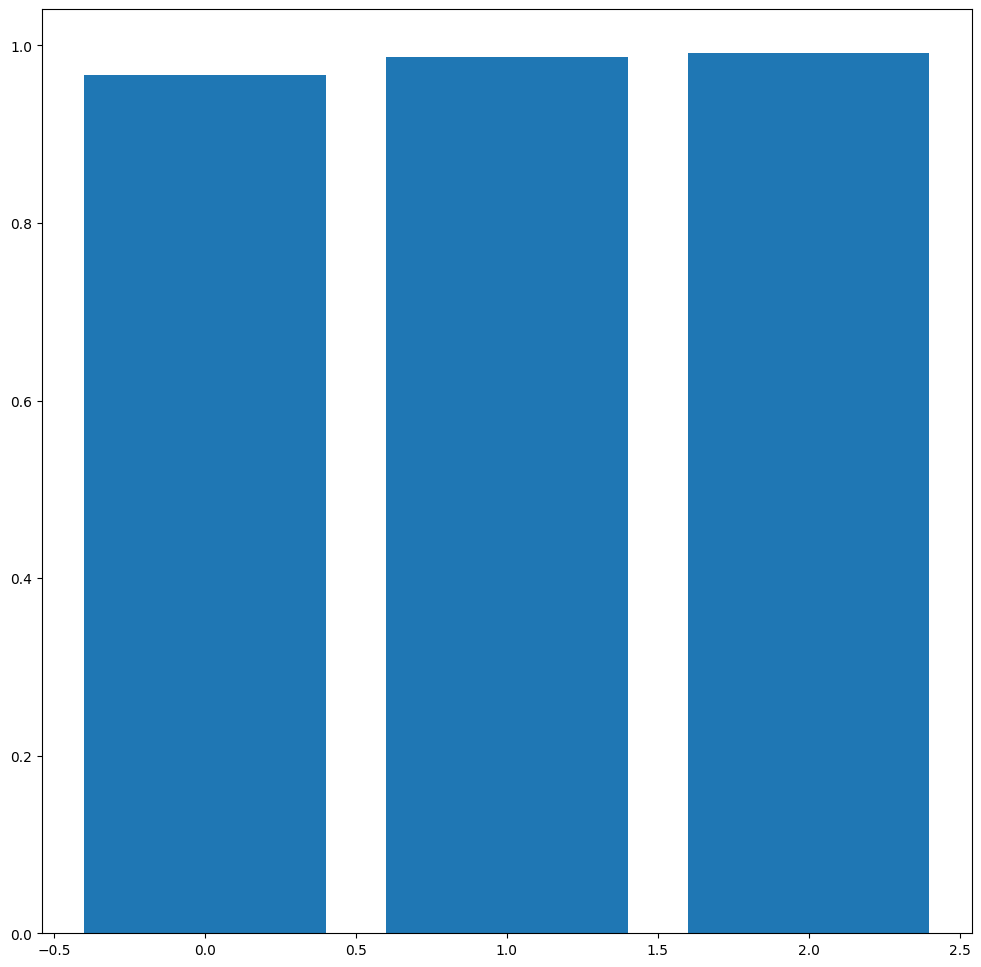

In [22]:
def ssim(img, filtered_img):
    """The SSIM similarity measure. Use the parameters from the paper
    as on the second to last slide from the lecture"""

    #Constants for the formula (origanlly from wikipedia cause the paper wasn't accesable)
    K1 = 0.01
    K2 = 0.03
    L = 256 - 1

    c1 = (K1 * L) ** 2
    c2 = (K2 * L) ** 2

    lum_mean_x = np.mean(img)
    lum_mean_y = np.mean(filtered_img)

    con_std_x = np.std(img)
    con_std_y = np.std(filtered_img)

    N = img.size
    struc_comb_dif = (1/(N-1)) * np.sum((img - lum_mean_x) * (filtered_img - lum_mean_y))

    ssim = ((2 * lum_mean_x * lum_mean_y + c1) * (2 * struc_comb_dif + c2) / ((lum_mean_x**2 + lum_mean_y**2 + c1) * (con_std_x**2 + con_std_y**2 +c2)))

    return ssim

for i, img in enumerate(images_for_jpeg):
    print(i)
    compressed_images = [images10[i], images50[i], images80[i]]
    plt.bar(range(len(compressed_images)),
             [ssim(img, comp) for comp in compressed_images])
    plt.show()